# TRAPPIST-1e

A single-planet climate report. TRAPPIST-1e is broadly temperate and roughly Earth-sized, and lies inside CLERO's core domain. We predict its steady-state climate and look at the surface map, area means and vertical structure.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from clero import Emulator, TRAPPIST1E
from clero.climate_analysis import (
    dayside_mean, field_map, global_mean, grid_records, ice_fraction_map, latitude_centers,
    latitude_weights, longitude_centers, nightside_mean, pressure_levels, profile_stats, stack_levels,
)

## Inputs

Stellar and bulk parameters are literature values for the TRAPPIST-1 system (Grimm et al. 2018). The atmosphere is not observationally constrained; let's assume an Earth-like 1 bar atmosphere with 400 ppm CO2. 

In [2]:
INPUTS = {**TRAPPIST1E, "P0": 1.0, "CO2": 4.0e-4, "CH4": 0.0}  # Grimm+2018 bulk params + an assumed 1 bar Earth-like atmosphere
emu = Emulator()
mean = emu.predict(INPUTS)
lat = latitude_centers(mean["surface_temperature"].shape[0])

## Surface temperature


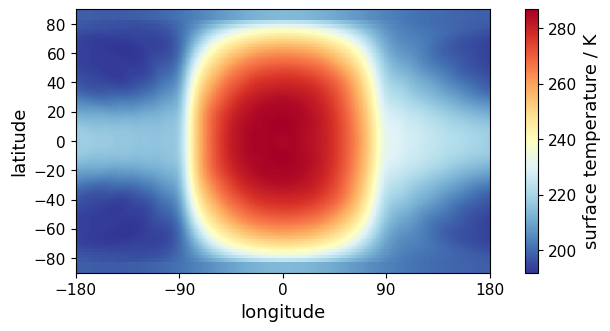

In [3]:
fig, ax = field_map(mean, "surface_temperature", lat=lat, units="surface temperature / K")

## Ice fraction

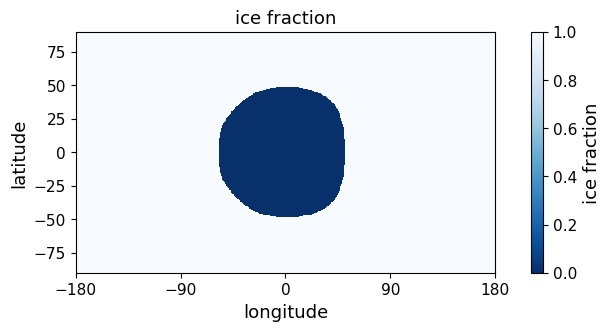

In [4]:
fig, ax = ice_fraction_map(mean, title="ice fraction")

## Area means

Dayside, nightside and global area-weighted means quantify the day–night contrast.

In [5]:
surface = mean["surface_temperature"]
{
    "dayside_mean": dayside_mean(surface, lat),
    "nightside_mean": nightside_mean(surface, lat),
    "global_mean": global_mean(surface, lat),
}


{'dayside_mean': 260.98987702479656,
 'nightside_mean': 208.3985144933324,
 'global_mean': 234.69419575906448}

## Surface temperature distribution

Weighting each grid cell by its area (proportional to cos of latitude) gives the fraction of the surface at each temperature. Tidally locked planets are often bimodal here: a broad cold nightside and a warmer dayside peak.

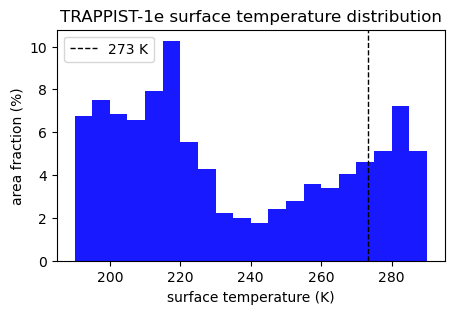

In [10]:
surface = mean["surface_temperature"]
w = latitude_weights(lat)
area = np.broadcast_to(w[:, None], surface.shape) / surface.shape[1] * 100.0  # per-cell area fraction (%)
bins = np.arange(np.floor(surface.min() / 5) * 5, surface.max() + 5, 5)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(surface.ravel(), bins=bins, weights=area.ravel(), color="blue", alpha=0.9)
ax.axvline(273.15, color="k", ls="--", lw=1, label="273 K")
ax.set(xlabel="surface temperature (K)", ylabel="area fraction (%)", title="TRAPPIST-1e surface temperature distribution")
ax.legend()
plt.show()

## Vertical structure

`stack_levels` assembles the ten model levels into a `(level, lat, lon)` array and `profile_stats` extracts characteristic columns. With `surface_key="surface_temperature"` and `pressure_levels(..., surface=True)` the surface value at `P0` is prepended, so each profile reaches the ground. The substellar column is warm and deep-convecting; the antistellar column is much colder.

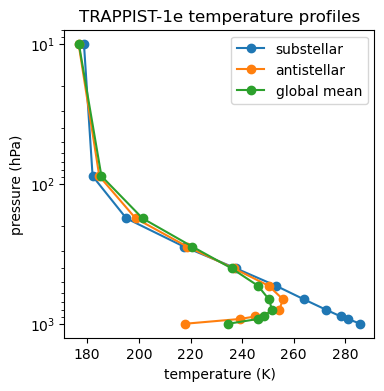

In [7]:
T = stack_levels(mean, "temperature", surface_key="surface_temperature")
prof = profile_stats(T, lat)
plev = pressure_levels(INPUTS["P0"], surface=True) / 100.0  # model levels + surface at P0, in hPa

fig, ax = plt.subplots(figsize=(4, 4))
for key, label in [("substellar_profile", "substellar"), ("antistellar_profile", "antistellar"), ("global_mean_profile", "global mean")]:
    ax.plot(prof[key], plev, marker="o", label=label)
ax.set(xlabel="temperature (K)", ylabel="pressure (hPa)", title="TRAPPIST-1e temperature profiles")
ax.set_yscale("log")
ax.invert_yaxis()
ax.legend()
plt.show()

## Export

`grid_records` flattens a field, or a `(level, lat, lon)` array, into one row per grid cell for CSV or JSON; `write_csv` saves it. Neither needs pandas or xarray.

In [8]:
lon = longitude_centers(mean["surface_temperature"].shape[1])
records = grid_records(mean["surface_temperature"], lat=lat, lon=lon, value_name="surface_temperature")
records[:4]

[{'lat': -85.7605871204438,
  'lon': -177.1875,
  'surface_temperature': 198.30519104003906},
 {'lat': -85.7605871204438,
  'lon': -171.5625,
  'surface_temperature': 198.20054626464844},
 {'lat': -85.7605871204438,
  'lon': -165.9375,
  'surface_temperature': 198.11956787109375},
 {'lat': -85.7605871204438,
  'lon': -160.3125,
  'surface_temperature': 198.06515502929688}]

These are point predictions. For a demo on propagating uncertainty see `uncertainty.ipynb`